In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

lauer_2025 = pd.read_csv('../data/lauer_2025.csv')
lauer_2026 = pd.read_csv('../data/lauer_2026.csv')

print(f"Lauer 2025: {len(lauer_2025)} pitches")
print(f"Lauer 2026: {len(lauer_2026)} pitches")

Lauer 2025: 1690 pitches
Lauer 2026: 314 pitches


In [2]:
from pybaseball import statcast_pitcher, playerid_lookup

ponce_info = playerid_lookup('ponce', 'cody')
print(ponce_info[['name_last', 'name_first', 'key_mlbam', 'mlb_played_first', 'mlb_played_last']])

Gathering player lookup table. This may take a moment.
  name_last name_first  key_mlbam  mlb_played_first  mlb_played_last
0     ponce       cody     664074            2020.0           2021.0


In [3]:
ponce_id = ponce_info['key_mlbam'].values[0]

# Ponce 2026 (injured after first start, limited data expected)
ponce_2026 = statcast_pitcher('2026-03-27', '2026-04-22', ponce_id)
print(f"Ponce 2026: {len(ponce_2026)} pitches")

# Ponce previous MLB stint (if any)
ponce_prev = statcast_pitcher('2021-01-01', '2025-12-31', ponce_id)
print(f"Ponce pre-2026 MLB: {len(ponce_prev)} pitches")

Gathering Player Data
Ponce 2026: 47 pitches
Gathering Player Data
Ponce pre-2026 MLB: 755 pitches


In [4]:
print("=== Lauer 2025 Pitch Mix ===")
print(lauer_2025['pitch_type'].value_counts())

print("\n=== Lauer 2026 Pitch Mix ===")
print(lauer_2026['pitch_type'].value_counts())

print("\n=== Lauer 2025 Avg Velocity ===")
velo_25 = lauer_2025.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
velo_25 = velo_25[velo_25['count'] >= 10].sort_values('mean', ascending=False)
print(velo_25.round(1))

print("\n=== Lauer 2026 Avg Velocity ===")
velo_26 = lauer_2026.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
velo_26 = velo_26[velo_26['count'] >= 5].sort_values('mean', ascending=False)
print(velo_26.round(1))

=== Lauer 2025 Pitch Mix ===
pitch_type
FF    782
FC    344
CU    242
SL    179
CH    134
SI      1
Name: count, dtype: int64

=== Lauer 2026 Pitch Mix ===
pitch_type
FF    145
CH     60
FC     52
SL     32
CU     25
Name: count, dtype: int64

=== Lauer 2025 Avg Velocity ===
            mean  count
pitch_type             
FF          91.7    782
FC          86.5    344
CH          85.0    134
SL          83.1    179
CU          75.0    242

=== Lauer 2026 Avg Velocity ===
            mean  count
pitch_type             
FF          90.6    145
FC          86.5     52
CH          83.2     60
SL          82.6     32
CU          74.7     25


Chart saved!


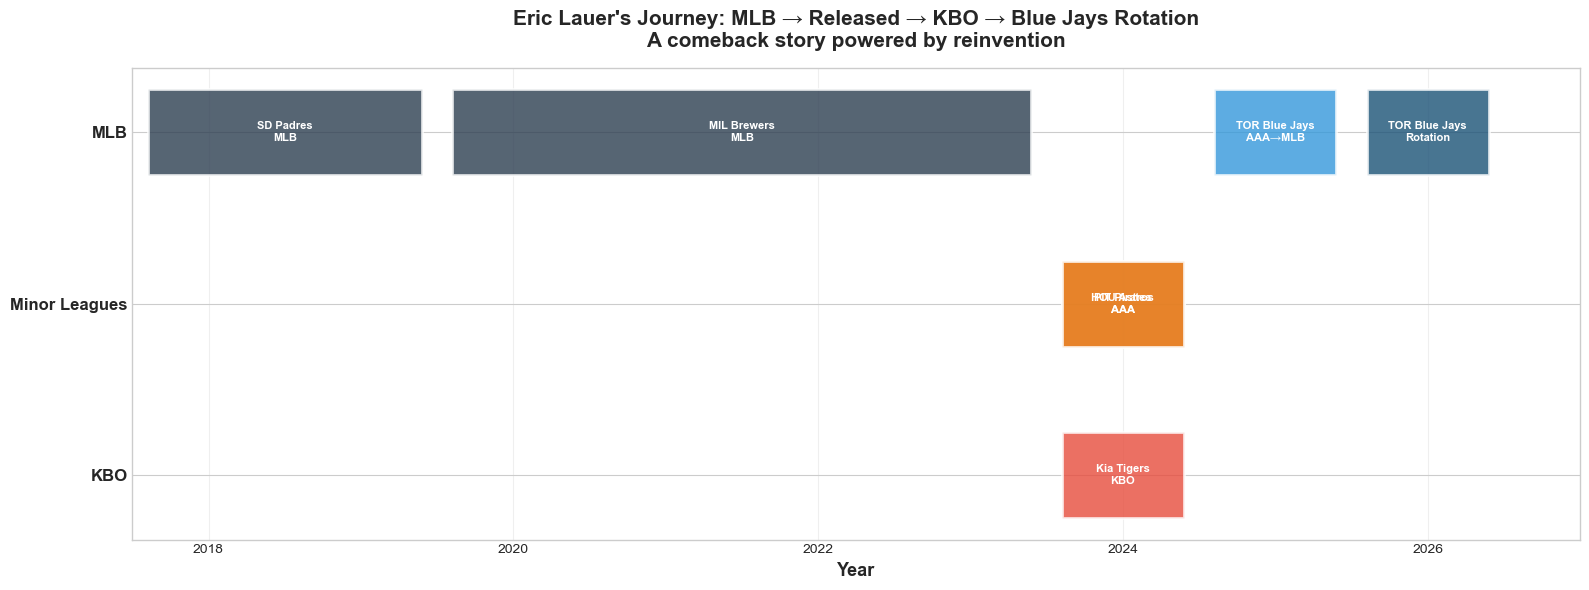

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

journey = [
    ('SD Padres\nMLB', 2018, 2019, '#2c3e50', 'MLB'),
    ('MIL Brewers\nMLB', 2020, 2023, '#2c3e50', 'MLB'),
    ('PIT Pirates\nAAA', 2024, 2024, '#e67e22', 'MiLB'),
    ('HOU Astros\nAAA', 2024, 2024, '#e67e22', 'MiLB'),
    ('Kia Tigers\nKBO', 2024, 2024, '#e74c3c', 'KBO'),
    ('TOR Blue Jays\nAAA→MLB', 2025, 2025, '#3498db', 'MLB'),
    ('TOR Blue Jays\nRotation', 2026, 2026, '#1a5276', 'MLB'),
]

y_positions = {
    'MLB': 3,
    'MiLB': 2,
    'KBO': 1
}

for i, (label, start, end, color, level) in enumerate(journey):
    y = y_positions[level]
    width = max(end - start + 0.8, 0.8)
    ax.barh(y, width, left=start - 0.4, height=0.5, 
            color=color, alpha=0.8, edgecolor='white', linewidth=2)
    ax.text(start + width/2 - 0.4, y, label, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['KBO', 'Minor Leagues', 'MLB'], fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_title("Eric Lauer's Journey: MLB → Released → KBO → Blue Jays Rotation\n"
             "A comeback story powered by reinvention",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(2017.5, 2027)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/04_lauer_journey.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


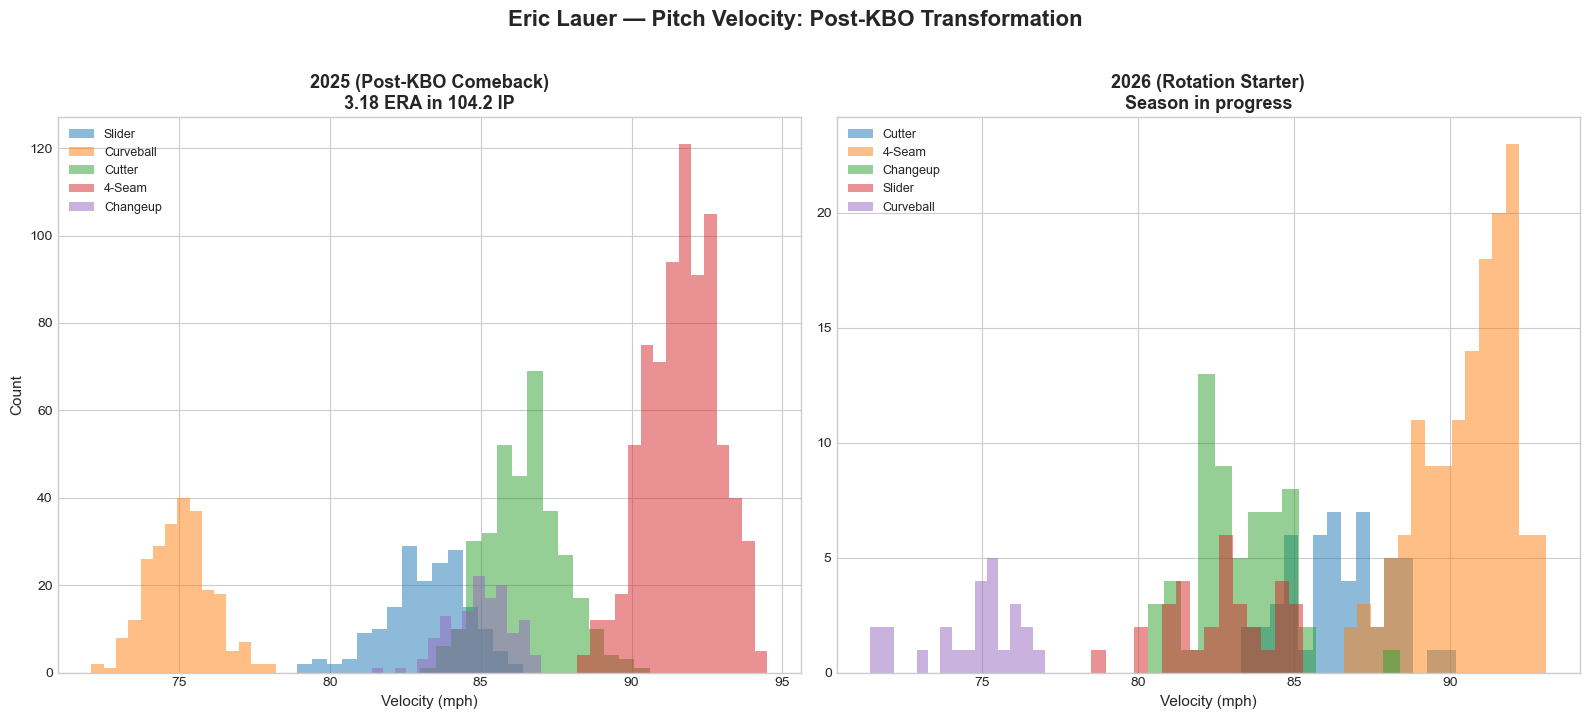

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pitch_names = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'SI': 'Sinker', 'CU': 'Curveball', 'FC': 'Cutter',
    'ST': 'Sweeper', 'KC': 'K-Curve'
}

# Left: 2025 pitch velocity distribution
ax1 = axes[0]
for pt in lauer_2025['pitch_type'].unique():
    data = lauer_2025[lauer_2025['pitch_type'] == pt]['release_speed'].dropna()
    if len(data) >= 20:
        ax1.hist(data, bins=15, alpha=0.5, 
                 label=pitch_names.get(pt, pt))
ax1.set_xlabel('Velocity (mph)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('2025 (Post-KBO Comeback)\n3.18 ERA in 104.2 IP', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# Right: 2026 pitch velocity distribution
ax2 = axes[1]
for pt in lauer_2026['pitch_type'].unique():
    data = lauer_2026[lauer_2026['pitch_type'] == pt]['release_speed'].dropna()
    if len(data) >= 5:
        ax2.hist(data, bins=15, alpha=0.5,
                 label=pitch_names.get(pt, pt))
ax2.set_xlabel('Velocity (mph)', fontsize=11)
ax2.set_title('2026 (Rotation Starter)\nSeason in progress',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle("Eric Lauer — Pitch Velocity: Post-KBO Transformation",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/05_lauer_velocity_comparison.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


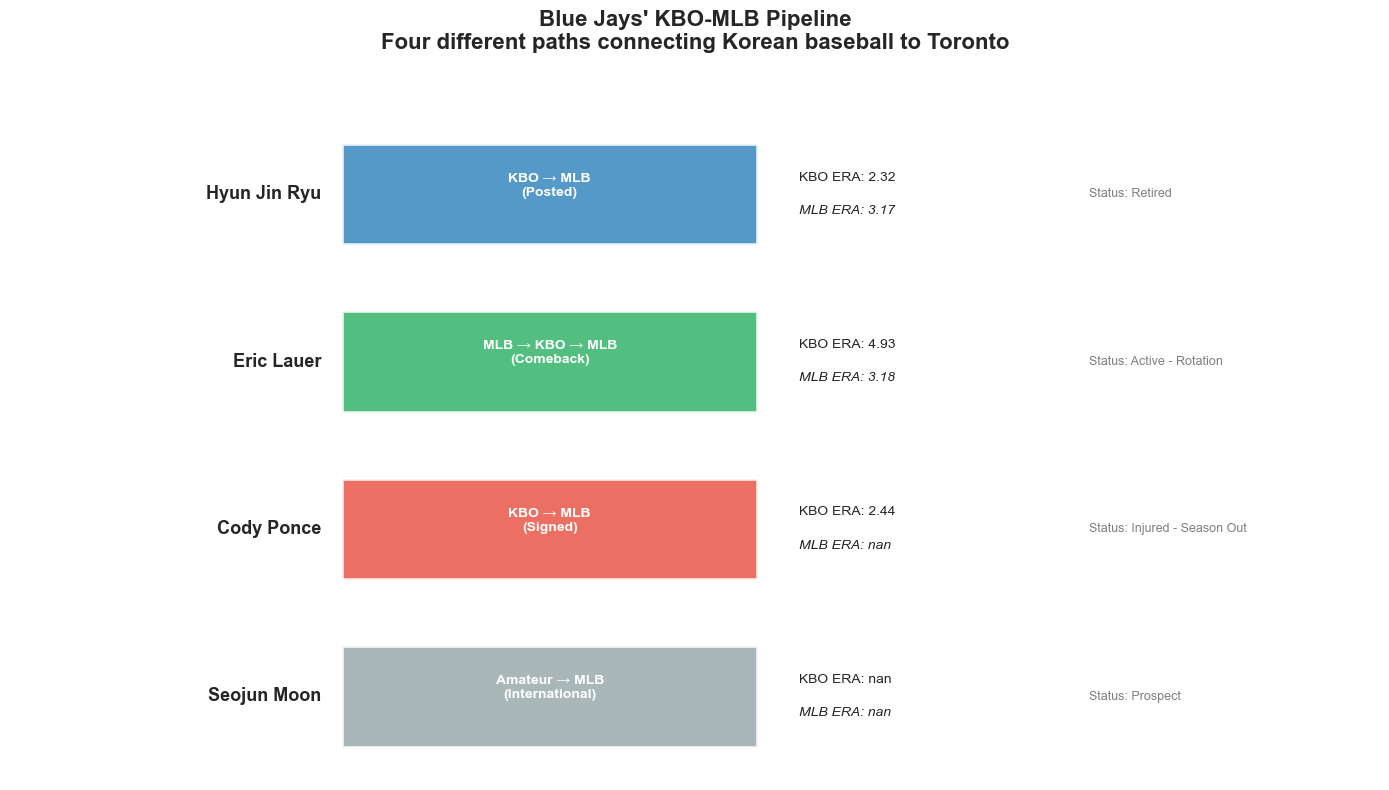

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

kbo_mlb_players = pd.DataFrame({
    'name': ['Hyun Jin Ryu', 'Eric Lauer', 'Cody Ponce', 'Seojun Moon'],
    'direction': ['KBO → MLB\n(Posted)', 'MLB → KBO → MLB\n(Comeback)', 
                  'KBO → MLB\n(Signed)', 'Amateur → MLB\n(International)'],
    'kbo_era': [2.32, 4.93, 2.44, None],
    'mlb_era': [3.17, 3.18, None, None],
    'blue_jays': [True, True, True, True],
    'status': ['Retired', 'Active - Rotation', 'Injured - Season Out', 'Prospect'],
    'color': ['#2980b9', '#27ae60', '#e74c3c', '#95a5a6']
})

for i, row in kbo_mlb_players.iterrows():
    y = len(kbo_mlb_players) - 1 - i
    
    ax.barh(y, 1, left=0, height=0.6, color=row['color'], alpha=0.8,
            edgecolor='white', linewidth=2)
    
    # Name and direction
    ax.text(-0.05, y, f"{row['name']}", ha='right', va='center',
            fontsize=13, fontweight='bold')
    ax.text(0.5, y + 0.05, row['direction'], ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    
    # Stats
    kbo_text = f"KBO ERA: {row['kbo_era']}" if row['kbo_era'] else "No KBO"
    mlb_text = f"MLB ERA: {row['mlb_era']}" if row['mlb_era'] else "TBD"
    ax.text(1.1, y + 0.1, kbo_text, fontsize=10, va='center')
    ax.text(1.1, y - 0.1, mlb_text, fontsize=10, va='center', fontstyle='italic')
    
    # Status
    ax.text(1.8, y, f"Status: {row['status']}", fontsize=9, va='center',
            color='gray')

ax.set_xlim(-0.8, 2.5)
ax.set_ylim(-0.5, len(kbo_mlb_players) - 0.3)
ax.axis('off')
ax.set_title("Blue Jays' KBO-MLB Pipeline\n"
             "Four different paths connecting Korean baseball to Toronto",
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../visualizations/06_kbo_mlb_pipeline.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()